# Data pipeline with keras and tf.data

The goal of this project is impelemente a data preprocessing pipeline using toolf from both Keras and tf.data module. Therefore I will use the ImageDataGenerator class in the tf.keras module to feed a network with trianing and test images from a local directory containing a subset of the LSUN dataset and train the model both with and without data augmentation. 

In [1]:
# Package and Libraries Imports

import tensorflow as tf
from tensorflow.keras.datasets import cifar100
import numpy as np
import matplotlib.pyplot as plt
import json

%matplotlib inline

##
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Flatten, Dense, Input
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


![church](data/lsun/church.png) ![class](data/lsun/classroom.png) ![confe](data/lsun/conference_room.png)

## The LSUN Dataset

I will use a subset of the [LSUN dataset](https://www.yf.io/p/lsun). This is a large scale image dataset with 10 scene and 20 object categories.  The three classes included in the subset are `chruch_outdoor`, `classroom` and `conference_room`.

* F. Yu, A. Seff, Y. Zhang, S. Song, T. Funkhouser and J. Xia. "LSUN: Construction of a Large-scale Image Dataset using Deep Learning with Humans in the Loop". arXiv:1506.03365, 10 Jun 2015 


The goal is to use the Keras preprocessing tools to construct a data ingestion and augmentation pipeline to train a neural network to classify the iamges into the three classes.

In [2]:

train_dir = 'data/lsun/train'
valid_dir = 'data/lsun/valid'
test_dir = 'data/lsun/test'


### Creating the Data Generator using the ImageDataGenerator Class

In [3]:

def get_ImageDataGenerator():

    image_data_generator = ImageDataGenerator(rescale=1./255.)

    return image_data_generator


In [4]:
image_gen = get_ImageDataGenerator()


Function that returns a generator object that will yield batches of images and labels from the training and test set directories.

In [5]:

def get_generator(image_data_generator, directory, seed=None):
    generator = image_data_generator.flow_from_directory(
        directory=directory,
        target_size=(64,64),
        batch_size=20,
        class_mode='categorical',
        shuffle=True,
        seed=seed
    )

    return generator

In [6]:
train_generator = get_generator(image_gen, train_dir)
vallid_generator = get_generator(image_gen, valid_dir)

Found 300 images belonging to 3 classes.
Found 120 images belonging to 3 classes.


## Displaying Sample Images and labels from the training set

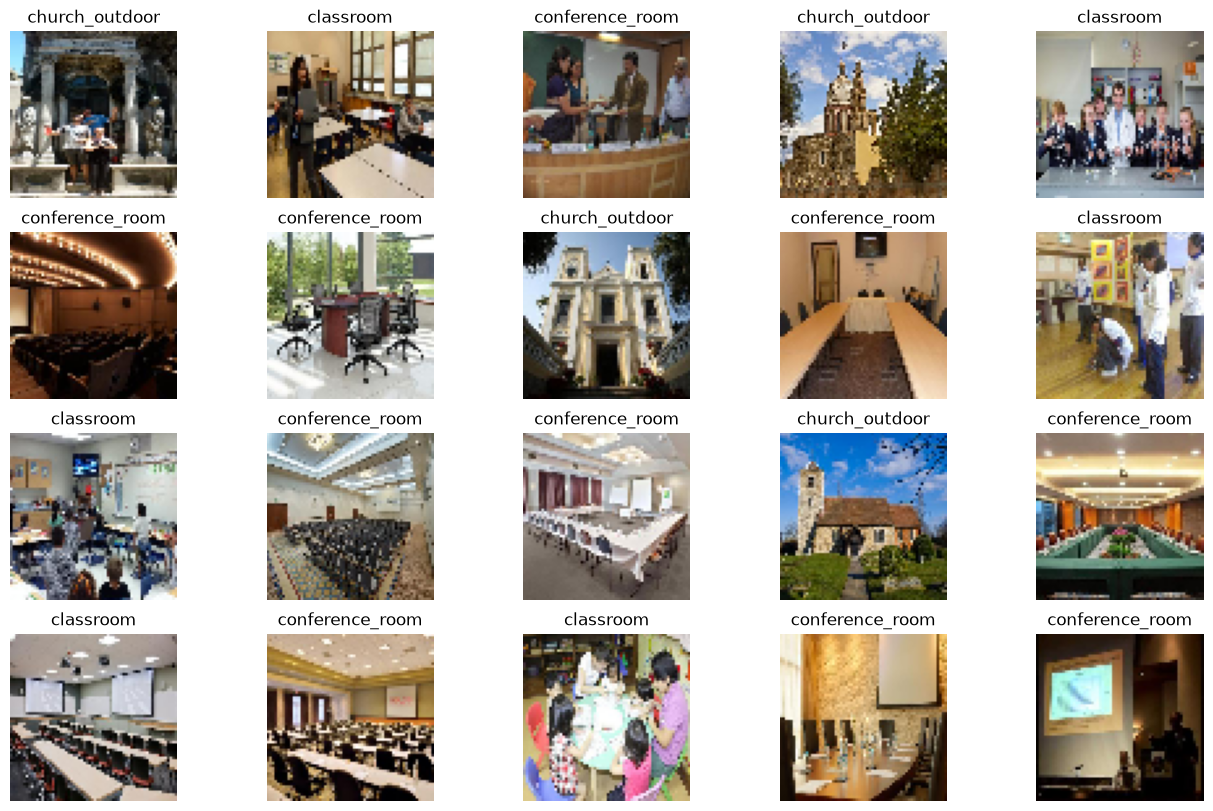

In [7]:
batch = next(train_generator)
batch_images = np.array(batch[0])
batch_labels = np.array(batch[1])
lsun_classes = ['church_outdoor', 'classroom', 'conference_room']


plt.figure(figsize=(16,10))
for i in range(20):
    ax = plt.subplot(4,5, i+1)
    plt.imshow(batch_images[i])
    plt.title(lsun_classes[np.where(batch_labels[i] == 1.)[0][0]])
    plt.axis('off')


In [8]:

train_generator = get_generator(image_gen, train_dir)

Found 300 images belonging to 3 classes.


## Building the Neural Network Model

In [9]:

def get_model(input_shape):

    inputs=Input(shape=input_shape)
    conv2d_1 = Conv2D(8, (8,8), padding='same', activation='relu')(inputs)
    maxpool1 = MaxPooling2D(pool_size=(2,2))(conv2d_1)
    conv2d_2 = Conv2D(4, (4,4), padding='same', activation='relu')(maxpool1)
    maxpool2 = MaxPooling2D(pool_size=(2,2))(conv2d_2)
    flatten = Flatten()(maxpool2)
    dense_1 = Dense(16, activation='relu')(flatten)
    outputs = Dense(3, activation='softmax')(dense_1)

    model = Model(inputs=inputs, outputs=outputs)

    optimizer = Adam(learning_rate=0.0005)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [10]:
lsun_model = get_model((64,64,3))
lsun_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 8)      │         1,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 4)      │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        16,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,511 (72.31 KB)

 Trainable params: 18,511 (72.31 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Neural Network Model

In [11]:

def train_model(model, train_gen, valid_gen, epochs):

    earlystopping = EarlyStopping(monitor='val_accuracy', patience=10)
    reduceLR = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                 min_lr=0.0001)

    history = model.fit(train_gen, validation_data=(valid_gen), epochs=epochs,
              callbacks=[earlystopping, reduceLR])

    return history


In [12]:
history = train_model(lsun_model, train_generator, vallid_generator,
                      epochs=50)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3300 - loss: 1.0890 - val_accuracy: 0.4167 - val_loss: 1.0754 - learning_rate: 5.0000e-04
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4400 - loss: 1.0228 - val_accuracy: 0.5750 - val_loss: 1.0060 - learning_rate: 5.0000e-04
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6133 - loss: 0.9290 - val_accuracy: 0.6583 - val_loss: 0.8610 - learning_rate: 5.0000e-04
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6833 - loss: 0.7838 - val_accuracy: 0.5833 - val_loss: 0.8326 - learning_rate: 5.0000e-04
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6833 - loss: 0.7336 - val_accuracy: 0.6667 - val_loss: 0.7593 - learning_rate: 5.0000e-04
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7300 - loss: 0.6633 - val_accuracy: 0.6583 - val_loss: 0.7682 - learning_rate: 5.0000e-04
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7400 

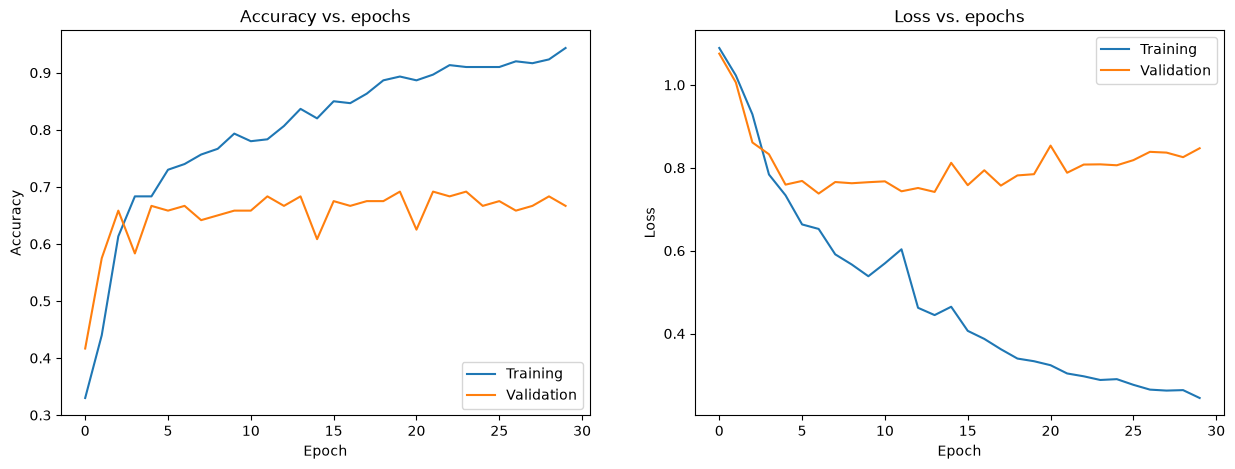

In [13]:

plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')

plt.subplot(122)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

We can notice overfitting in the two plots, growing discrepancy between the training and validation loss and accuracy. One way to mitigate this is use data augmentation. Given a limited dataset, we can improve the performance by applying random modifications to the images in the trainig data.

# Creating a New Data Generator with Data Augmentation

In [14]:


def get_ImageDataGenerator_augmented():

    image_data_generator = ImageDataGenerator(rescale=1./255.,
                        rotation_range=30,
                        brightness_range=(0.5,1.5),
                        horizontal_flip = True)

    return image_data_generator

In [15]:
image_gen_aug = get_ImageDataGenerator_augmented()

In [16]:

valid_generator_aug = get_generator(image_gen_aug, valid_dir)
train_generator_aug = get_generator(image_gen_aug, train_dir, seed=10)

Found 120 images belonging to 3 classes.
Found 300 images belonging to 3 classes.


In [17]:

train_generator = get_generator(image_gen, train_dir, seed=10)

Found 300 images belonging to 3 classes.


# Displaying sample augmented images and labels from the training set

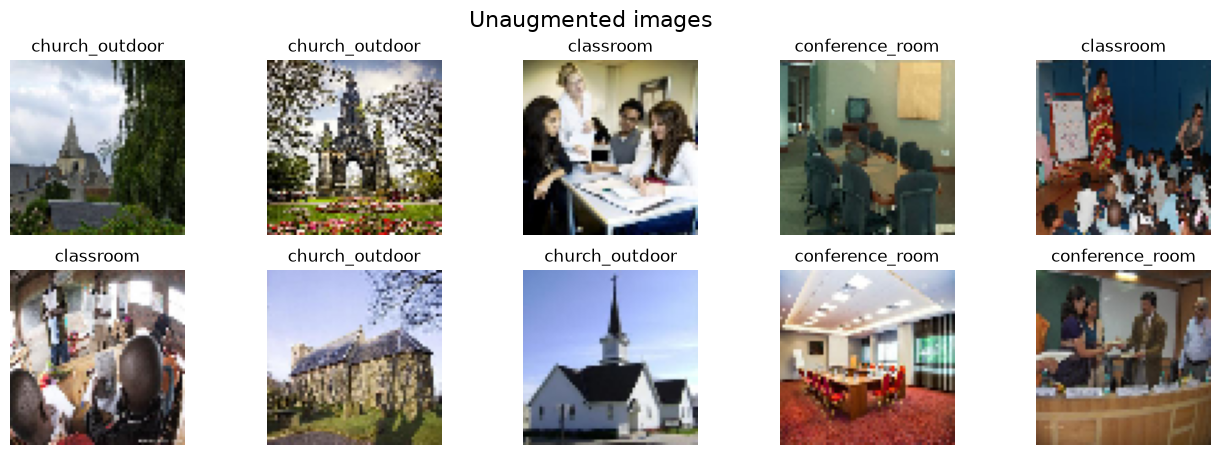

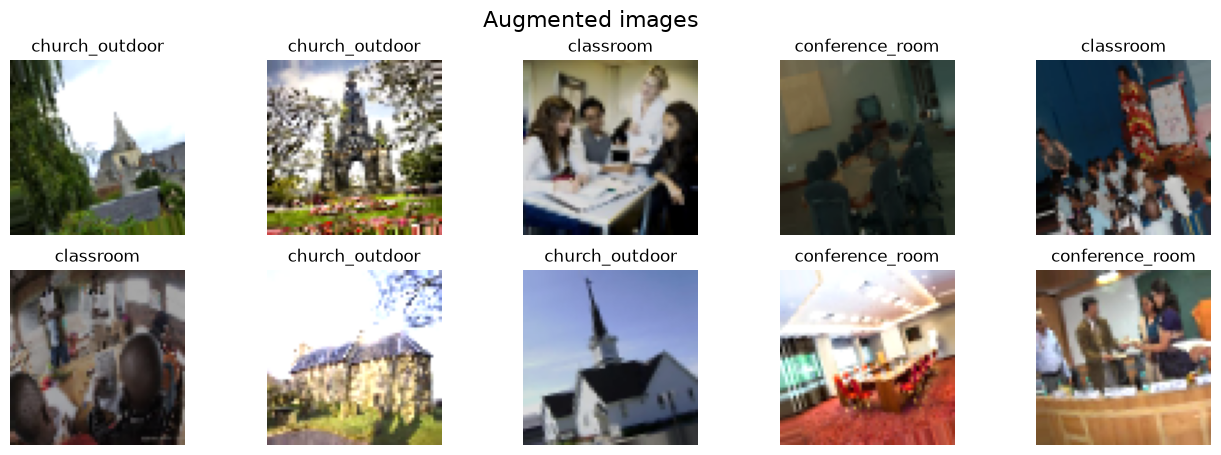

In [18]:
batch = next(train_generator)
batch_images = np.array(batch[0])
batch_labels = np.array(batch[1])

aug_batch = next(train_generator_aug)
aug_batch_images = np.array(aug_batch[0])
aug_batch_labels = np.array(aug_batch[1])

plt.figure(figsize=(16,5))
plt.suptitle("Unaugmented images", fontsize=16)
for n, i in enumerate(np.arange(10)):
    ax = plt.subplot(2, 5, n+1)
    plt.imshow(batch_images[i])
    plt.title(lsun_classes[np.where(batch_labels[i] == 1.)[0][0]])
    plt.axis('off')
plt.figure(figsize=(16,5))
plt.suptitle("Augmented images", fontsize=16)
for n, i in enumerate(np.arange(10)):
    ax = plt.subplot(2, 5, n+1)
    plt.imshow(aug_batch_images[i])
    plt.title(lsun_classes[np.where(aug_batch_labels[i] == 1.)[0][0]])
    plt.axis('off')


In [19]:

train_generator_aug = get_generator(image_gen_aug, train_dir)

Found 300 images belonging to 3 classes.


In [20]:

lsun_new_model = get_model((64,64,3))

In [21]:

history_augmented = train_model(lsun_new_model, train_generator_aug,
                                valid_generator_aug, epochs=50)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3533 - loss: 1.0993 - val_accuracy: 0.3500 - val_loss: 1.0988 - learning_rate: 5.0000e-04
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4267 - loss: 1.0902 - val_accuracy: 0.4083 - val_loss: 1.0841 - learning_rate: 5.0000e-04
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4167 - loss: 1.0782 - val_accuracy: 0.3750 - val_loss: 1.0611 - learning_rate: 5.0000e-04
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4733 - loss: 1.0471 - val_accuracy: 0.5167 - val_loss: 0.9909 - learning_rate: 5.0000e-04
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5133 - loss: 1.0106 - val_accuracy: 0.6417 - val_loss: 0.9093 - learning_rate: 5.0000e-04
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5900 - loss: 0.9018 - val_accuracy: 0.5833 - val_loss: 0.8393 - learning_rate: 5.0000e-04
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6533 

## Plotting yhe learning curves

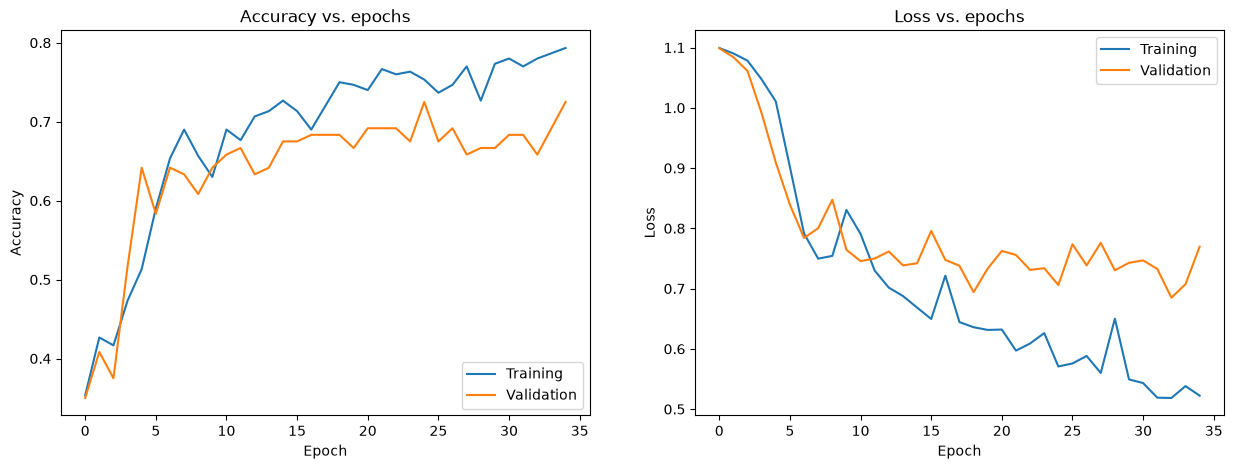

In [22]:
# Run this cell to plot accuracy vs epoch and loss vs epoch

plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(history_augmented.history['accuracy'])
plt.plot(history_augmented.history['val_accuracy'])

plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')

plt.subplot(122)
plt.plot(history_augmented.history['loss'])
plt.plot(history_augmented.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

We can see an improvement in the overfitting.

## Getting predictions using the trained model

In [23]:
num_batches= 3
seed = 25
test_generator = get_generator(image_gen_aug, test_dir, seed=seed)
predictions = lsun_new_model.predict(test_generator, steps=num_batches)

Found 300 images belonging to 3 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


Found 300 images belonging to 3 classes.
[26 14 27 55]


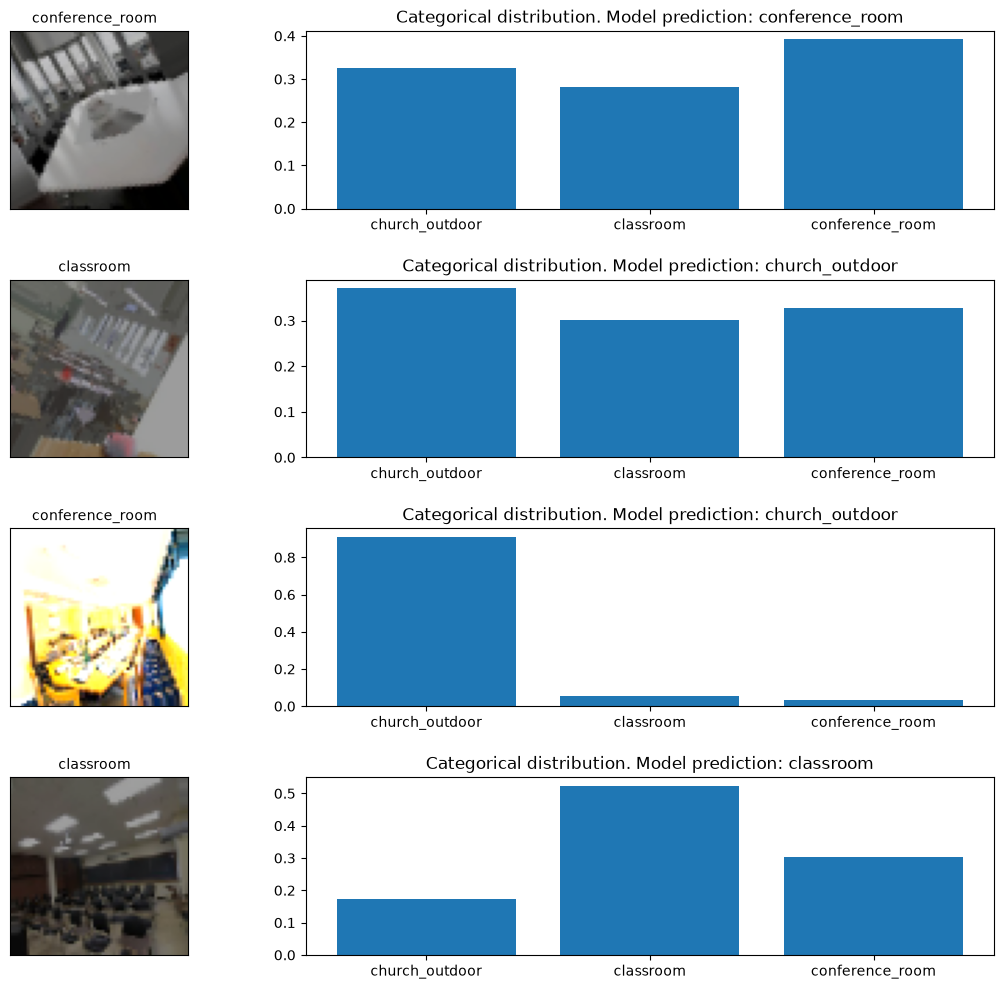

In [24]:

test_generator = get_generator(image_gen_aug, test_dir, seed=seed)
batches = []
for i in range(num_batches):
    batches.append(next(test_generator))
    
batch_images = np.vstack([b[0] for b in batches])
batch_labels = np.concatenate([b[1].astype(np.int32) for b in batches])

# Randomly select images from the batch
inx = np.random.choice(predictions.shape[0], 4, replace=False)
print(inx)

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
fig.subplots_adjust(hspace=0.4, wspace=-0.2)

for n, i in enumerate(inx):
    axes[n, 0].imshow(batch_images[i])
    axes[n, 0].get_xaxis().set_visible(False)
    axes[n, 0].get_yaxis().set_visible(False)
    axes[n, 0].text(30., -3.5, lsun_classes[np.where(batch_labels[i] == 1.)[0][0]], 
                    horizontalalignment='center')
    axes[n, 1].bar(np.arange(len(predictions[i])), predictions[i])
    axes[n, 1].set_xticks(np.arange(len(predictions[i])))
    axes[n, 1].set_xticklabels(lsun_classes)
    axes[n, 1].set_title(f"Categorical distribution. Model prediction: {lsun_classes[np.argmax(predictions[i])]}")
    
plt.show()

# TF.Data

![cifar](data/cifar100/cifar100.png)

## The CIFAR-100 Dataset

Now I will use the [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html). This image dataset has 100 classes with 500 training images and 100 test images per class. 

* A. Krizhevsky. "Learning Multiple Layers of Features from Tiny Images". April 2009 

The goal is to use the tf.data module preprocessing tools to construct a data ingestion pipeline including filtering and function mapping over the dataset to train a neural network to classify the images.

### Load the dataset

In [25]:
(train_data, train_labels), (test_data, test_labels) = cifar100.load_data(label_mode='fine')

with open('data/cifar100/cifar100_labels.json', 'r') as j:
    cifar_labels = json.load(j)


### Display sample images and labels fro the training set

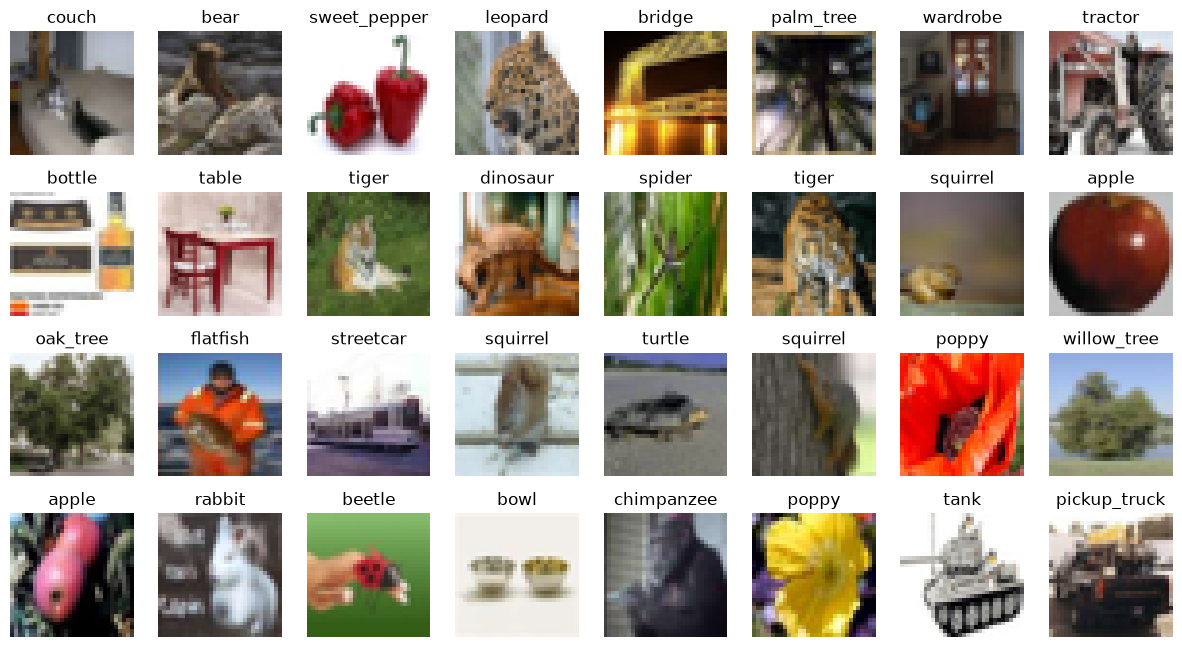

In [27]:
plt.figure(figsize=(15,8))
inx = np.random.choice(train_data.shape[0], 32, replace=False)
for n, i in enumerate(inx):
    ax = plt.subplot(4, 8, n+1)
    plt.imshow(train_data[i])
    plt.title(cifar_labels[int(np.squeeze(train_labels[i]))])
    plt.axis('off')

## Creating the Dataset object for the train and test images

In [28]:


def create_dataset(data, labels):

    obj_dataset = tf.data.Dataset.from_tensor_slices((data, labels))

    return obj_dataset

In [29]:
train_dataset = create_dataset(train_data, train_labels)
test_dataset = create_dataset(test_data, test_labels)

In [30]:
print(train_dataset.element_spec)
print(test_dataset.element_spec)

(TensorSpec(shape=(32, 32, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(1,), dtype=tf.int64, name=None))
(TensorSpec(shape=(32, 32, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(1,), dtype=tf.int64, name=None))


## Filtering the Dataset

In [31]:
def filter_classes(dataset, classes):

    classes_tensor = tf.cast(classes, dtype=tf.int64)

    def is_in_classes(image, label):
        matches = tf.equal(tf.cast(label, dtype=tf.int64), classes_tensor)
        return tf.math.reduce_any(matches)
    
    filtered_dataset = dataset.filter(is_in_classes)

    return filtered_dataset

In [32]:
cifar_classes = [0, 29, 99]

train_dataset = filter_classes(train_dataset, cifar_classes)
test_dataset = filter_classes(test_dataset, cifar_classes)

## Applying map functions to the Dataset

In [33]:

def map_labels(dataset):

    classes_tensor = tf.constant(cifar_classes, dtype=tf.int64)
    def one_hot_encode(image, label):
        class_index = tf.argmax(tf.cast(tf.equal(tf.cast(label, tf.int64), classes_tensor), tf.int64))
        one_hot_label = tf.one_hot(class_index, depth=len(cifar_classes))
        return image, one_hot_label
    mapped_dataset = dataset.map(one_hot_encode)

    return mapped_dataset

In [34]:
train_dataset = map_labels(train_dataset)
test_dataset = map_labels(test_dataset)

In [37]:

def map_images(dataset):

    def process_image(image, label):
        image = tf.cast(image, tf.float32)/255.0
        image = tf.reduce_mean(image, axis=-1, keepdims=True)

        return image, label

    mapped_image = dataset.map(process_image)

    return mapped_image

In [38]:
train_dataset_bw = map_images(train_dataset)
test_dataset_bw = map_images(test_dataset)

# Displaying a batch of processed images

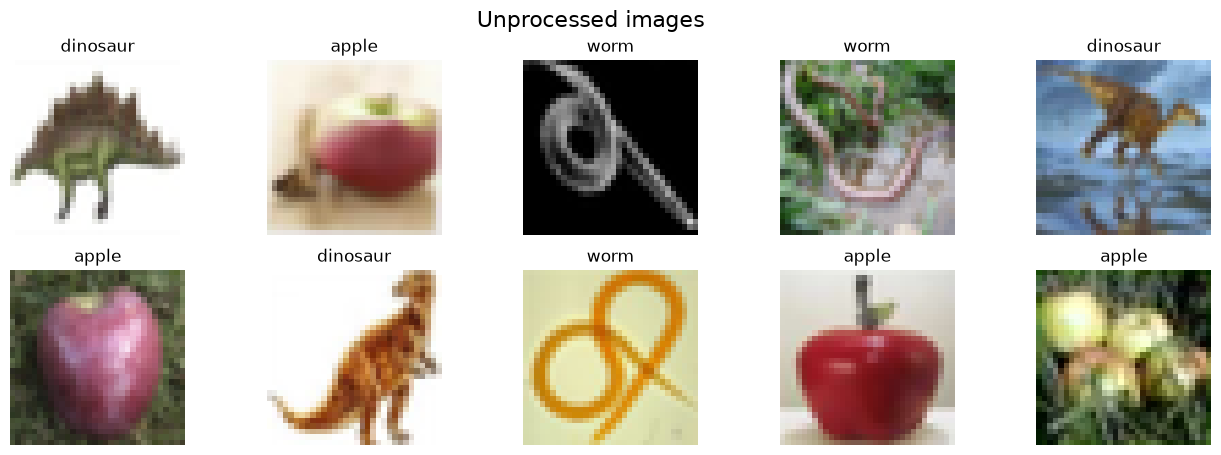

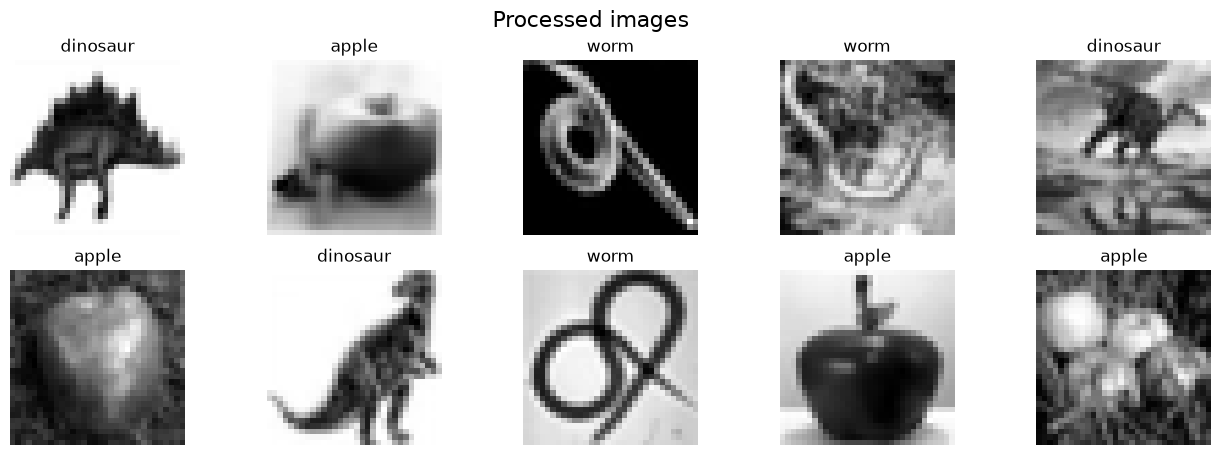

In [39]:
plt.figure(figsize=(16,5))
plt.suptitle("Unprocessed images", fontsize=16)
for n, elem in enumerate(train_dataset.take(10)):
    images, labels = elem
    ax = plt.subplot(2, 5, n+1)
    plt.title(cifar_labels[cifar_classes[np.where(labels == 1.)[0][0]]])
    plt.imshow(np.squeeze(images), cmap='gray')
    plt.axis('off')
    
plt.figure(figsize=(16,5))
plt.suptitle("Processed images", fontsize=16)
for n, elem in enumerate(train_dataset_bw.take(10)):
    images_bw, labels_bw = elem
    ax = plt.subplot(2, 5, n+1)
    plt.title(cifar_labels[cifar_classes[np.where(labels_bw == 1.)[0][0]]])
    plt.imshow(np.squeeze(images_bw), cmap='gray')
    plt.axis('off')

### Batch and Shuffle the Dataset Object

In [40]:
train_dataset_bw = train_dataset_bw.batch(10)
train_dataset_bw = train_dataset_bw.shuffle(100)

test_dataset_bw = test_dataset_bw.batch(10)
test_dataset_bw = test_dataset_bw.shuffle(100)

# Training a nerual netwoek model

In [41]:
cifar_model = get_model((32,32,1))

In [42]:

history = cifar_model.fit(train_dataset_bw, validation_data=test_dataset_bw,
                          epochs=15)

Epoch 1/15


c:\Users\ramir\OneDrive\Documents\ESTUDIO\DEEP LEARNING\Tensorflow 2 for Deep Learning\PROYECTOS 2\tf2-image-data-pipelines-lsun-cifar100\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


    150/Unknown 1s 3ms/step - accuracy: 0.4613 - loss: 1.0609

c:\Users\ramir\OneDrive\Documents\ESTUDIO\DEEP LEARNING\Tensorflow 2 for Deep Learning\PROYECTOS 2\tf2-image-data-pipelines-lsun-cifar100\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4613 - loss: 1.0609 - val_accuracy: 0.5733 - val_loss: 0.9886
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5667 - loss: 0.9443 - val_accuracy: 0.6733 - val_loss: 0.8288
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6407 - loss: 0.8216 - val_accuracy: 0.6967 - val_loss: 0.7519
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6820 - loss: 0.7441 - val_accuracy: 0.7167 - val_loss: 0.7379
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7333 - loss: 0.6699 - val_accuracy: 0.7100 - val_loss: 0.6672
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7500 - loss: 0.6234 - val_accuracy: 0.7433 - val_loss: 0.6349
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7707 - loss: 0.5875 - val_accuracy: 0.7733 - val_loss: 0.6140
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7813 - loss: 0.5581 - val_accuracy: 0.7567 - val_

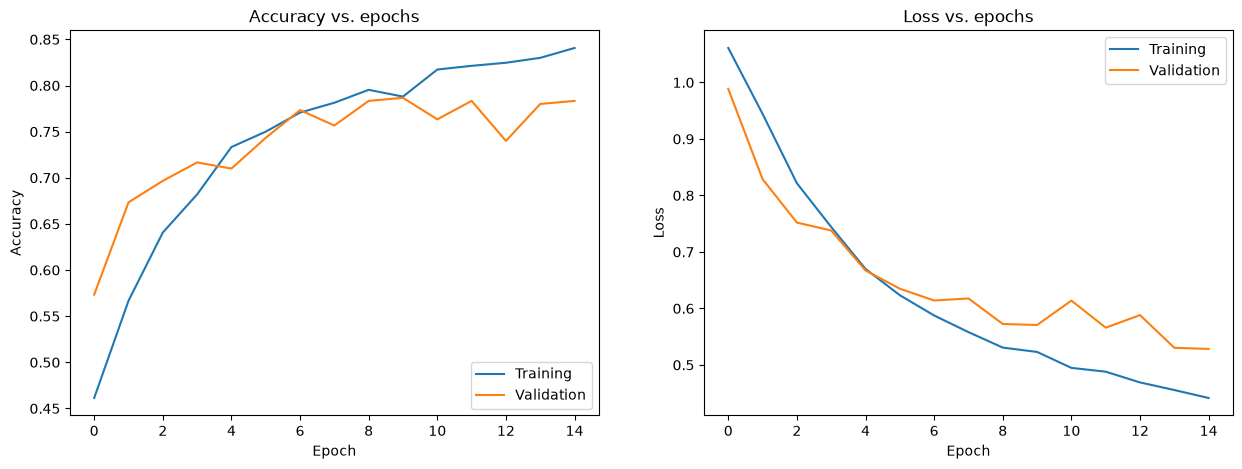

In [43]:
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')

plt.subplot(122)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

In [44]:
test_dataset = test_dataset.batch(10)
iter_test_dataset = iter(test_dataset)

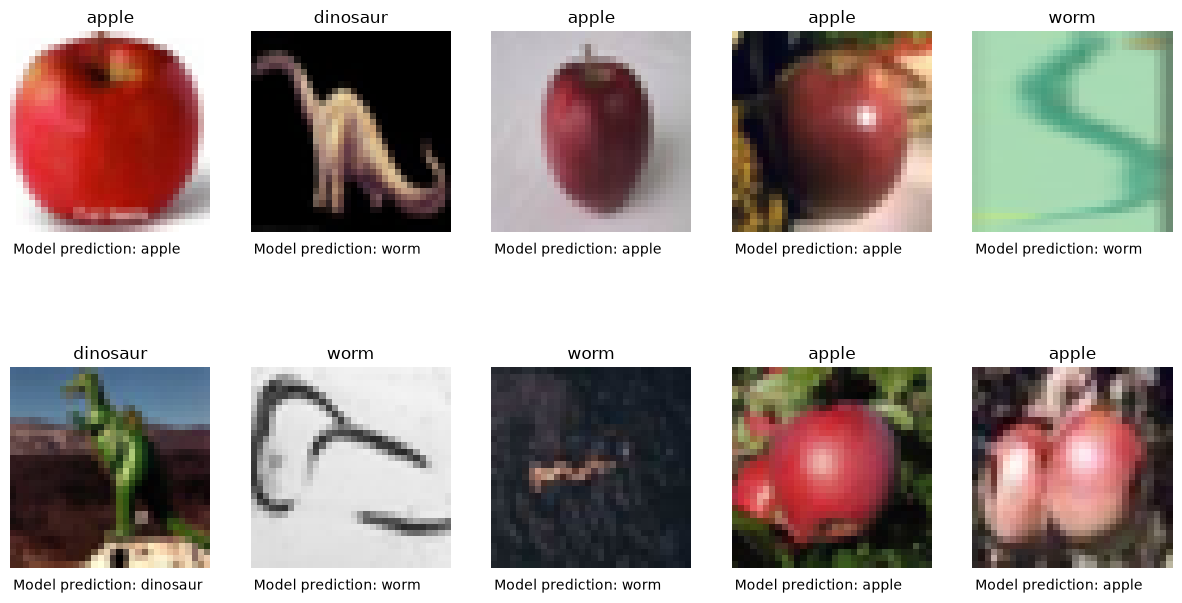

In [46]:
plt.figure(figsize=(15,8))
inx = np.random.choice(test_data.shape[0], 18, replace=False)
images, labels = next(iter_test_dataset)
probs = cifar_model(tf.reduce_mean(tf.cast(images, tf.float32), axis=-1, keepdims=True) / 255.)
preds = np.argmax(probs, axis=1)
for n in range(10):
    ax = plt.subplot(2, 5, n+1)
    plt.imshow(images[n])
    plt.title(cifar_labels[cifar_classes[np.where(labels[n].numpy() == 1.0)[0][0]]])
    plt.text(0, 35, "Model prediction: {}".format(cifar_labels[cifar_classes[preds[n]]]))
    plt.axis('off')